# DTSC691 - Machine Learning Project by Diana Ogendi

# Graph Based and Contrastive Learning Fraud Detection on Financial Data

**Project Objective:**
To develop an adaptive Machine Learning framework that integrates Graph Neural Networks (GNNs) with Contrastive Learning to detect structural anomalies and other emerging patterns that traditional row‑based supervised models fail to identify. The system will learn the underlying structure of “normal” financial behavior and flag deviations even when labeled fraud examples are sparse, incomplete, or outdated.

**Motivation for choosing this project:**
Fraud is relational and adaptive: Modern fraud rings operate through networks of coordinated accounts, devices, wallets, and merchants. Traditional supervised models treat transactions as isolated rows, missing the relational structure where fraud hides. GNNs directly model these relationships, making them uniquely suited for detecting collusion, mule networks, and coordinated attacks.

Supervised fraud models fail on new fraud patterns: Financial institutions face constant concept drift since fraudsters change tactics, channels, and behavioral signatures. Contrastive learning and unsupervised anomaly detection allow the model to learn the structure of normal behavior and flag deviations even when no labeled fraud examples exist.

**Scope:**
Build a graph representation of financial or blockchain transactions capturing multi entity relationships.
Develop a contrastive learning framework to learn robust embeddings of normal vs. anomalous behavior.
Detect structural anomalies and emerging fraud patterns without relying on labeled data.
Compare GNN based and contrastive models against classical baselines such as XGBoost, Logistic Regression and Isolation Forest.
Evaluate robustness to imbalance, noise, and temporal drift.
Deliver a lightweight User Interface (UI) for graph visualization and model explanations.

**Dataset: IEEE-CIS Fraud Detection**  https://www.kaggle.com/competitions/ieee-fraud-detection/data
The dataset contains rich metadata (identity and transactions) that supports graph construction and anomaly modeling. It also contains a high imbalance of classes, missing values and inconsistent formats. The dataset is already time split 50/50 into train/test splits and bifurcated into two primary tables joined by a unique TransactionID.
Note: Not all transactions have corresponding identity information.

**Transaction Table**
Contains features such as: TransactionDT (timedelta/not an actual timestamp), TransactionAMT (USD amount) and **Categorical Features** - ProductCD, card1 - card6, addr1, addr2, P_emaildomain, R_emaildomain, M1 - M9.

**Identity Table**
Contains features such as: **Categorical Features** - DeviceType, DeviceInfo, id_12 - id_38

In [1]:
# Essential Imports for Project

# Core
import os, gc, time, warnings
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Graph
import networkx as nx
import scipy.sparse as sp

# PyTorch + PyG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader, NeighborLoader
from torch_geometric.nn import SAGEConv

# Contrastive
from torch.nn import CosineSimilarity

# Baselines
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
import xgboost as xgb

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

In [2]:
# Load the data
train_tr = pd.read_csv("train_transaction.csv")
train_id = pd.read_csv("train_identity.csv")
test_tr = pd.read_csv("test_transaction.csv")
test_id = pd.read_csv("test_identity.csv")

In [3]:
print("train_tr:", train_tr.shape)
print("train_id:", train_id.shape)
print("test_tr:", test_tr.shape)
print("test_id:", test_id.shape)

train_tr: (590540, 394)
train_id: (144233, 41)
test_tr: (506691, 393)
test_id: (141907, 41)


In [4]:
# Since the identity table is sparse, we will perform a left join to merge train/test transaction and identity tables on transaction_id
train = train_tr.merge(train_id, on="TransactionID", how="left")
test = test_tr.merge(test_id, on="TransactionID", how="left")

In [5]:
# merged train and test dimensions
print("train:", train.shape)
print("test:", test.shape)

train: (590540, 434)
test: (506691, 433)


In [6]:
train["TransactionID"].nunique()

590540

In [7]:
test["TransactionID"].nunique()

506691

There are no duplicate transactions in the train/test datasets. Every row represents a unique event. There is a one-to-one mapping between the row index and the TransactionID column.

In [8]:
# Summary table including datatype, missing values and unique counts of variables
summary_table = pd.DataFrame({
    "Unique Values": train.nunique(),
    "Data Type": train.dtypes,
    "Missing Values": train.isnull().sum(),
    "% Missing": (train.isnull().sum() / len(train) * 100).round(2)
})

# Sorting by Unique Values
sorted_summary = summary_table.sort_values(by="Unique Values", ascending=False)

# Ensure ALL rows are displayed
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(sorted_summary)

                Unique Values Data Type  Missing Values  % Missing
TransactionID          590540     int64               0       0.00
TransactionDT          573349     int64               0       0.00
id_02                  115655   float64          449668      76.15
V307                    37367   float64              12       0.00
V127                    24414   float64             314       0.05
V308                    23064   float64              12       0.00
TransactionAmt          20902   float64               0       0.00
V310                    19136   float64              12       0.00
V306                    16210   float64              12       0.00
V317                    15184   float64              12       0.00
V203                    14951   float64          450909      76.36
V128                    14507   float64             314       0.05
card1                   13553     int64               0       0.00
V264                    13358   float64          460110      7

Since the dataset is huge (~1.8 GB), to reduce memory usage:

**1. Convert object/string columns to category**
Converting every object column to category is dangerous since: **some columns have too many unique values and converting them can increase memory**
I created a function that solves this by applying a data‑driven rule: **Only convert if fewer than 5% of rows are unique**.

**2. Float Columns have 1 decimal digit with Column(V159) having 6 decimal digits**
The same function downcasts float64 to float32 which will cut memory usage significantly and speed up plotting while giving more than enough precison for this dataset. 

In [9]:
# Function to reduce memory usage by downcasting datatypes and converting object/string to category
def reduce_mem_usage(df):
    """
    Downcasts numeric columns and converts objects to category.
    Reports memory usage before and after.
    """
    mem_before = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            if pd.api.types.is_integer_dtype(col_type):
                # unsigned ints
                if c_min >= 0:
                    if c_max < np.iinfo(np.uint8).max:
                        df[col] = df[col].astype(np.uint8)
                    elif c_max < np.iinfo(np.uint16).max:
                        df[col] = df[col].astype(np.uint16)
                    elif c_max < np.iinfo(np.uint32).max:
                        df[col] = df[col].astype(np.uint32)
                else:
                    # signed ints
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)

            elif pd.api.types.is_float_dtype(col_type):
                df[col] = df[col].astype(np.float32)

        else:
            df[col] = df[col].astype("category")

    mem_after = df.memory_usage(deep=True).sum() / 1024**2
    reduction = (mem_before - mem_after) / mem_before * 100

    print(f"Memory: {mem_before:.2f} MB → {mem_after:.2f} MB ({reduction:.1f}% reduction)")

    return df

In [10]:
# Call function on our train dataset 
train = reduce_mem_usage(train)

Memory: 2567.09 MB → 924.43 MB (64.0% reduction)


In [11]:
# Sync test to train’s datatypes
common_cols = train.columns.intersection(test.columns)

for col in common_cols:
    if train[col].dtype.name == "category":
        # Convert test to category first
        test[col] = test[col].astype("category")
        
        # Align categories to train
        test[col] = test[col].cat.set_categories(train[col].cat.categories)
    else:
        # Normal numeric casting
        test[col] = test[col].astype(train[col].dtype)

In [12]:
# Double check that the train and test datasets match
# This identifies any columns that ended up with different types

# Get the set of columns common to both dataframes
common_cols = train.columns.intersection(test.columns)

# Compare datatypes only for those common columns
mismatch = (train[common_cols].dtypes != test[common_cols].dtypes)

# Print any that don't match
if mismatch.any():
    print("Mismatched columns found:")
    print(train[common_cols].dtypes[mismatch])
else:
    print("Success! All common column types match.")

# Also, check what columns are unique to each (usually just 'isFraud')
print(f"\nColumns in Train but not Test: {set(train.columns) - set(test.columns)}")

Success! All common column types match.

Columns in Train but not Test: {'id_33', 'id_02', 'id_05', 'id_18', 'id_24', 'id_03', 'id_27', 'id_01', 'id_34', 'id_32', 'id_15', 'id_04', 'id_20', 'id_14', 'id_38', 'id_09', 'id_28', 'id_16', 'id_29', 'id_23', 'id_30', 'id_25', 'id_08', 'id_06', 'id_37', 'id_11', 'id_21', 'id_13', 'id_12', 'id_17', 'id_22', 'isFraud', 'id_35', 'id_10', 'id_26', 'id_36', 'id_07', 'id_19', 'id_31'}


In [13]:
# Re-run Summary table including datatype, missing values and unique counts of variables
summary_table = pd.DataFrame({
    "Unique Values": train.nunique(),
    "Data Type": train.dtypes,
    "Missing Values": train.isnull().sum(),
    "% Missing": (train.isnull().sum() / len(train) * 100).round(2)
})

# Sorting by Unique Values
sorted_summary = summary_table.sort_values(by="Unique Values", ascending=False)

# Ensure ALL rows are displayed
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(sorted_summary)

                Unique Values Data Type  Missing Values  % Missing
TransactionID          590540    uint32               0       0.00
TransactionDT          573349    uint32               0       0.00
id_02                  115655   float32          449668      76.15
V307                    37367   float32              12       0.00
V127                    24414   float32             314       0.05
V308                    23064   float32              12       0.00
TransactionAmt          20902   float32               0       0.00
V310                    19136   float32              12       0.00
V306                    16210   float32              12       0.00
V317                    15184   float32              12       0.00
V203                    14951   float32          450909      76.36
V128                    14507   float32             314       0.05
card1                   13553    uint16               0       0.00
V264                    13358   float32          460110      7

## Methodology & Analysis

### EDA (Exploratory Data Analysis)

#### 1. Univariate Analysis

Fraud vs Non-Fraud differences in single variables.

**1. Two-Panel Bar Chart(Distribution of Fraud)**
We begin EDA with univariate analysis of the target variable isFraud, examining both its class distribution and the proportion of total transaction value associated with each class.

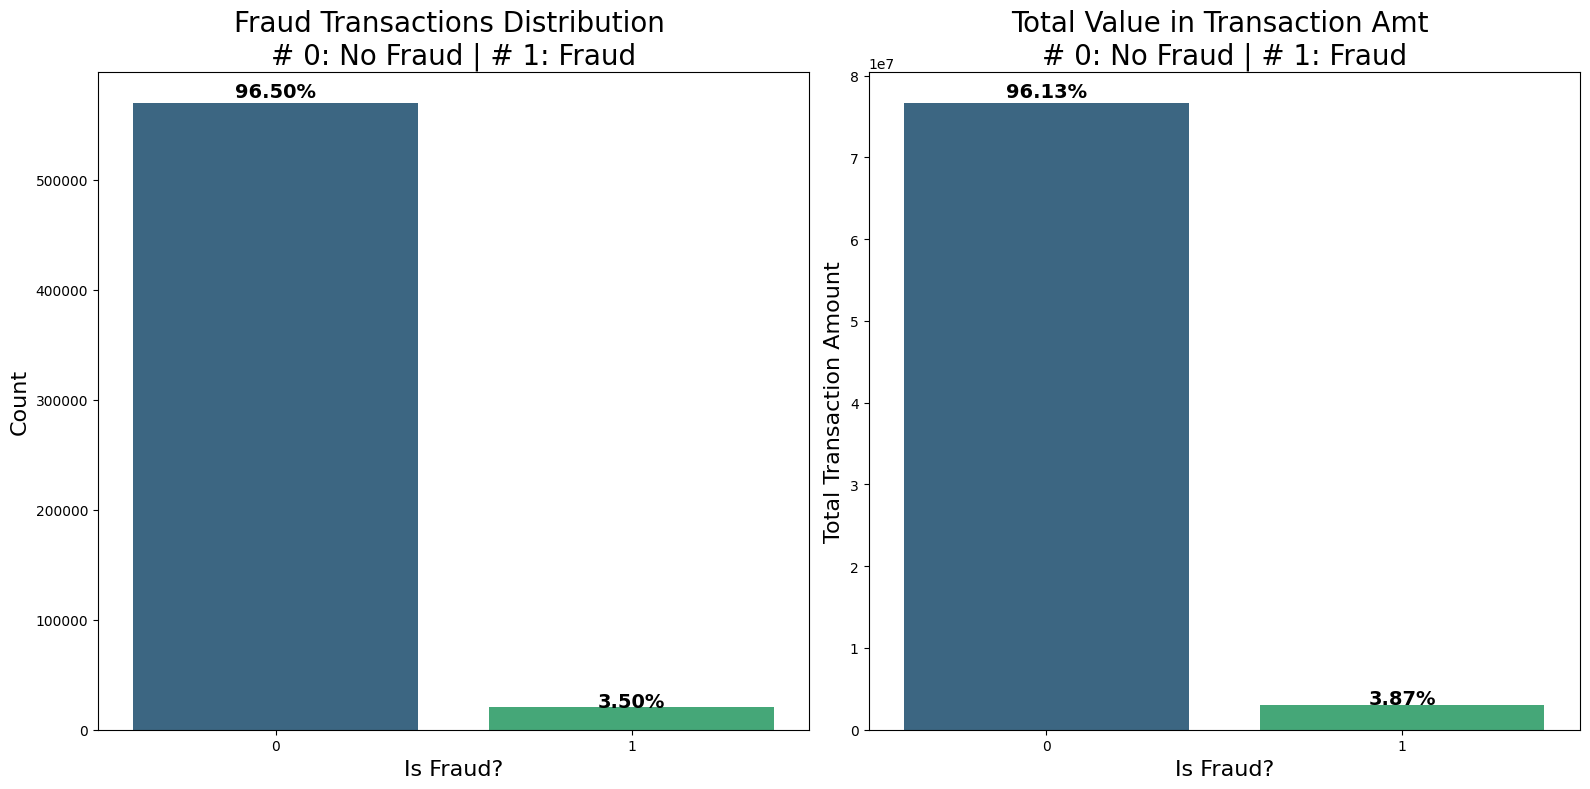

In [14]:
# Plot the distribution of fraud
total = len(train)
total_amt = train.groupby(["isFraud"])["TransactionAmt"].sum().sum()

plt.figure(figsize=(16, 8))

# --- Plot 1: Transaction Volume (Count) ---
plt.subplot(121)
g = sns.countplot(x="isFraud", data=train, palette="viridis")
g.set_title("Fraud Transactions Distribution \n# 0: No Fraud | # 1: Fraud", fontsize=20)
g.set_xlabel("Is Fraud?", fontsize=16)
g.set_ylabel("Count", fontsize=16)

# Annotate with percentages of Total Volume
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x() + p.get_width()/2.,
            height * 1.01,
            "{:1.2f}%".format(height/total*100),
            ha="center", fontsize=14, fontweight="bold") 

# --- Plot 2: Transaction Value (Sum) ---
perc_amt = train.groupby(["isFraud"])["TransactionAmt"].sum().reset_index()

plt.subplot(122)
g1 = sns.barplot(x="isFraud", y="TransactionAmt", data=perc_amt, palette="viridis")
g1.set_title("Total Value in Transaction Amt \n# 0: No Fraud | # 1: Fraud", fontsize=20)
g1.set_xlabel("Is Fraud?", fontsize=16)
g1.set_ylabel("Total Transaction Amount", fontsize=16)

# Annotate with percentages of Total Money
for p in g1.patches:
    height = p.get_height()
    g1.text(p.get_x() + p.get_width()/2.,
            height * 1.01,
            "{:1.2f}%".format(height/total_amt * 100),
            ha="center", fontsize=14, fontweight="bold") 

plt.tight_layout()
plt.show()

Fraudulent transactions represent only 3.50% of all activity, confirming the severe class imbalance typical of fraud detection problems. However, these transactions account for 3.87% of total transaction value, indicating that fraud tends to involve slightly higher‑value transactions. This imbalance underscores the need for models that prioritize recall and precision over accuracy, as even a small number of missed fraud cases can result in disproportionate financial loss.

---

**2. Histograms and KDE plots to analyze the distribution of TransactionAmt**
I created a sub-dataframe with 5 columns intended to use for visualizations and made a 20k sample due to large size of dataset and memory issues with KDE Plots.

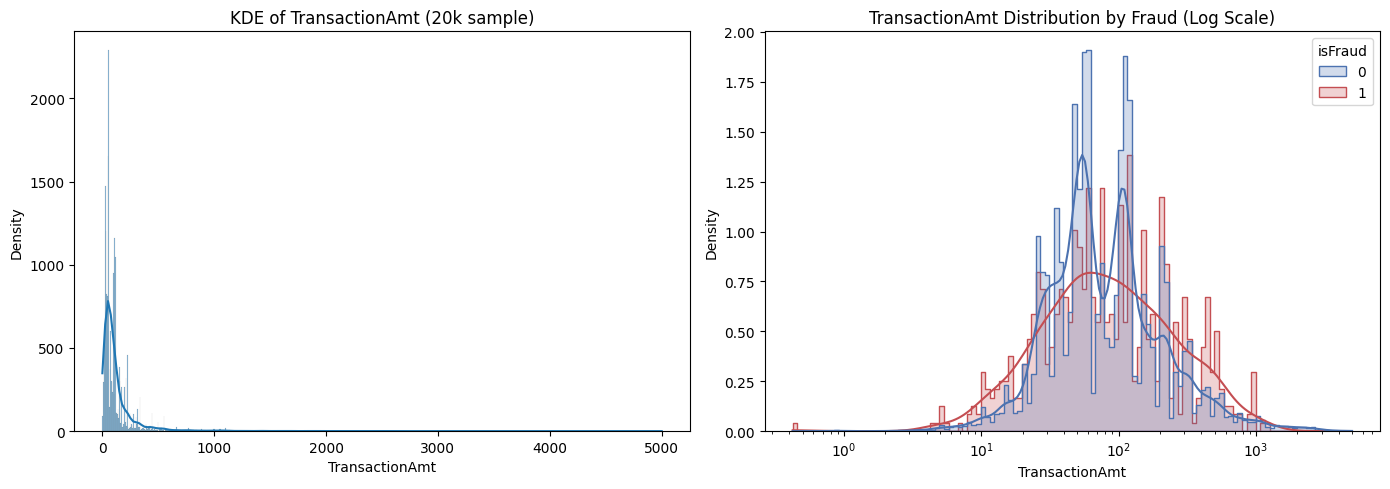

In [15]:
# Create a sub-dataframe with the 5 main columns for visualization
cols = ["TransactionAmt", "ProductCD", "card4", "card6", "isFraud"]
df_univ = train[cols]

# Sample 20k to minimize memory usage since KDE is RAM intensive
sample = df_univ.sample(20000, random_state=42)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Simple KDE ---
sns.histplot(
    sample["TransactionAmt"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("KDE of TransactionAmt (20k sample)")
axes[0].set_xlabel("TransactionAmt")
axes[0].set_ylabel("Density")

# --- Right: Fraud vs Non-Fraud KDE (Log Scale) ---
sns.histplot(
    data=sample,
    x="TransactionAmt",
    hue="isFraud",
    kde=True,
    log_scale=True,
    element="step",
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#C44E52"],
    ax=axes[1]
)
axes[1].set_title("TransactionAmt Distribution by Fraud (Log Scale)")
axes[1].set_xlabel("TransactionAmt")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

While Figure 1 highlights the extreme skewness and presence of outliers in the financial data, Figure 2 utilizes a log-transformed scale to compare the density of fraudulent versus legitimate transactions. The significant overlap between the two distributions demonstrates that TransactionAmt is not a standalone predictor for fraud. This observation justifies the shift toward Graph-Based and Contrastive Learning methods, which can leverage relational cues and high-dimensional feature embeddings to identify anomalies that are otherwise indistinguishable in the univariate feature space.

---

**3. Frequency bar charts for categorical variables like ProductCD and card information to identify dominant classes**

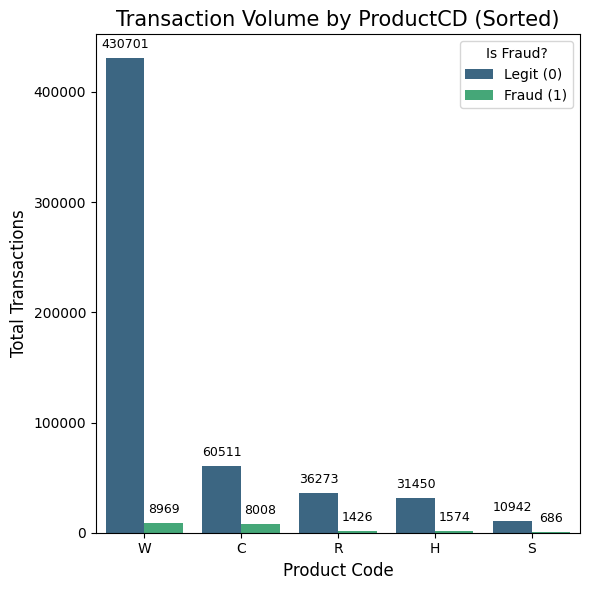

In [16]:
# Get the sorted order of ProductCD by total frequency
# Using df_univ with all rows and 5 columns
product_order = df_univ["ProductCD"].value_counts().index

# Set the figure size
plt.figure(figsize=(6, 6))

# Create a countplot with 'isFraud' as the hue
# This shows the volume of each product type sorted from highest to lowest
ax = sns.countplot(data=df_univ, x="ProductCD", order=product_order, hue="isFraud", palette="viridis"
)
# Add labels and aesthetics
plt.title("Transaction Volume by ProductCD (Sorted)", fontsize=15)
plt.xlabel("Product Code", fontsize=12)
plt.ylabel("Total Transactions", fontsize=12)
plt.legend(title="Is Fraud?", labels=["Legit (0)", "Fraud (1)"])

# Add text labels on top of the bars to see exact counts
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only label bars that have data
        ax.annotate(f"{int(height)}", 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha="center", va="bottom", 
                    fontsize=9, color="black", xytext=(0, 5),
                    textcoords="offset points")

plt.tight_layout()
plt.show()

Fraud is not isolated to a single product code. It exists across all product categories but at different intensities with product C having a proportionately higher fraud count relative to its volume.

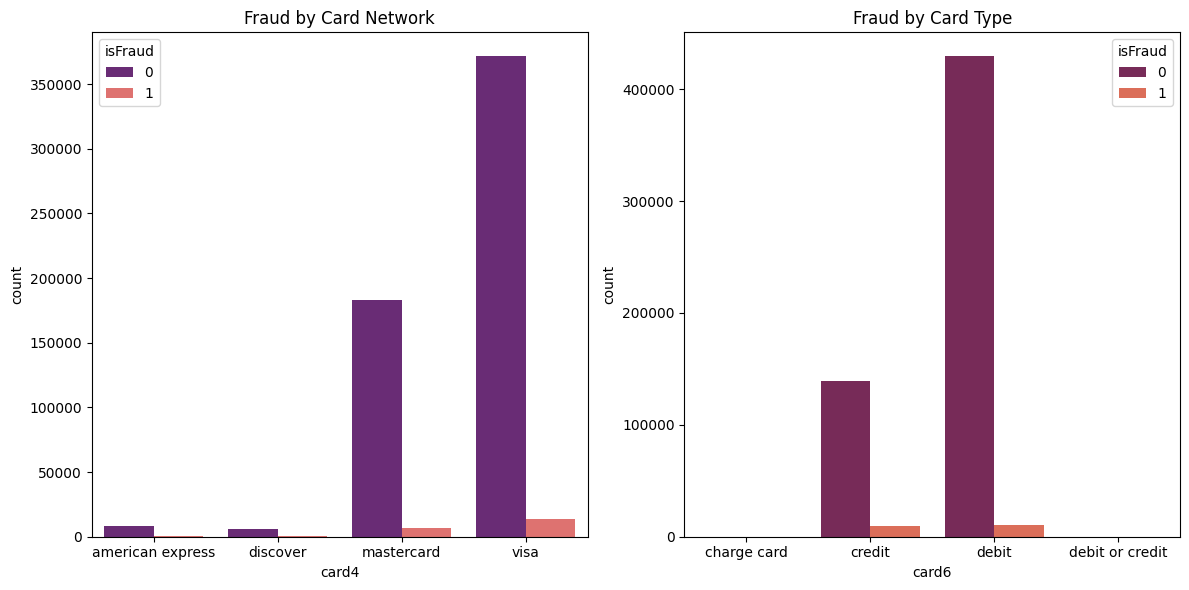

In [17]:
# Set up a grid for 2 bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- 1. Card Network (Visa, Mastercard, etc.)
sns.countplot(data=df_univ, x="card4", hue="isFraud", ax=axes[0], palette="magma")
axes[0].set_title('Fraud by Card Network')

# --- 2. Card Type (Credit vs Debit)
sns.countplot(data=df_univ, x="card6", hue="isFraud", ax=axes[1], palette="rocket")
axes[1].set_title("Fraud by Card Type")

plt.tight_layout()
plt.show()

The 2 bar charts show us that Visa and debit cards have the highest fraud counts, but this is likely driven by their dominance in overall transaction volume rather than a higher inherent fraud risk. These bar charts show raw counts, so they reflect customer behavior more than fraud behavior.

In real banking systems, debit cards often have lower fraud‑detection thresholds and fewer friction steps because they use verified funds, which can allow more borderline transactions through. However, to determine whether debit or Visa cards are actually riskier, we need to look at fraud proportions (fraud rate per category), not just total fraud counts.


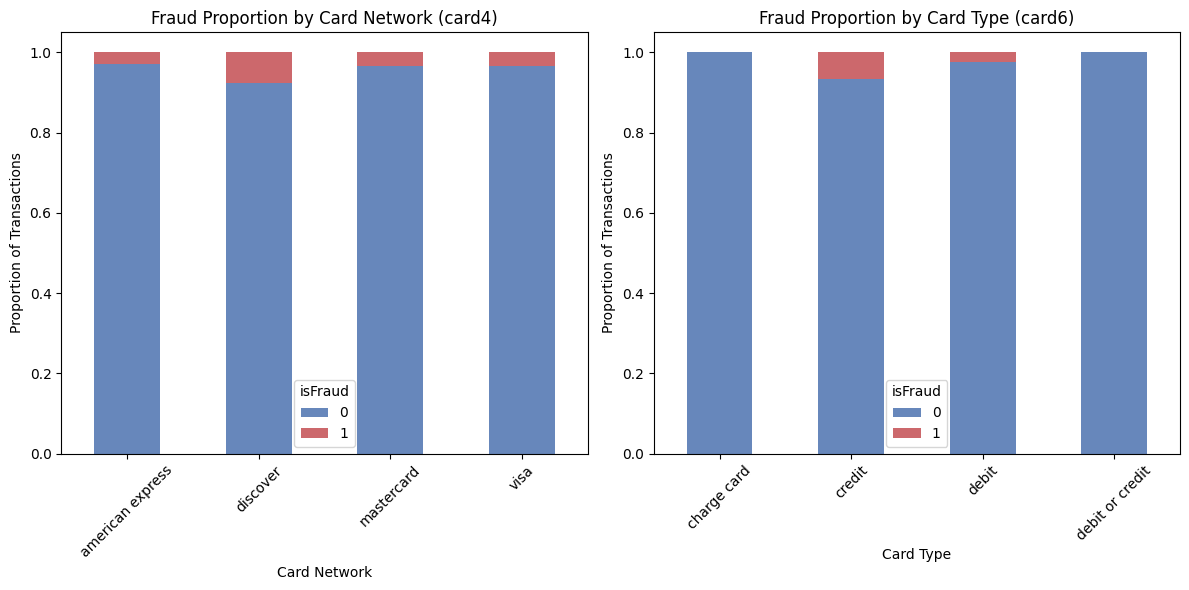

In [18]:
# Normalized fraud rates for card network (card4)
card4_risk = pd.crosstab(
    df_univ["card4"],
    df_univ["isFraud"],
    normalize="index"
)
# Normalized fraud rates for card type (card6)
card6_risk = pd.crosstab(
    df_univ["card6"],
    df_univ["isFraud"],
    normalize="index"
)
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Left plot: card4
card4_risk.plot(
    kind="bar",
    stacked=True,
    color=["#4C72B0", "#C44E52"],
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title("Fraud Proportion by Card Network (card4)")
axes[0].set_ylabel("Proportion of Transactions")
axes[0].set_xlabel("Card Network")
axes[0].tick_params(axis="x", rotation=45)

# Right plot: card6
card6_risk.plot(
    kind="bar",
    stacked=True,
    color=["#4C72B0", "#C44E52"],
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title("Fraud Proportion by Card Type (card6)")
axes[1].set_ylabel("Proportion of Transactions")
axes[1].set_xlabel("Card Type")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The normalized bar plots confirm that while Visa and Debit cards represent the majority of transaction volume (Exposure), they do not necessarily correlate with the highest relative risk.

#### 2. Bivariate Analysis

How pairs of variables interact with Fraud

**1. Box plot to compare TransactionAmt across isFraud labels**
   
Because TransactionAmt has such a massive range (from $1-$30,000+), a standard box plot will look like a flat line. We will use a log scale to see the actual distribution of the "whisker" and "median".

In [19]:
# Create a sub-dataframe with the 4 main columns for visualization
cols2 = ["TransactionAmt", "P_emaildomain", "isFraud", "R_emaildomain"]
df_bivar = train[cols2]

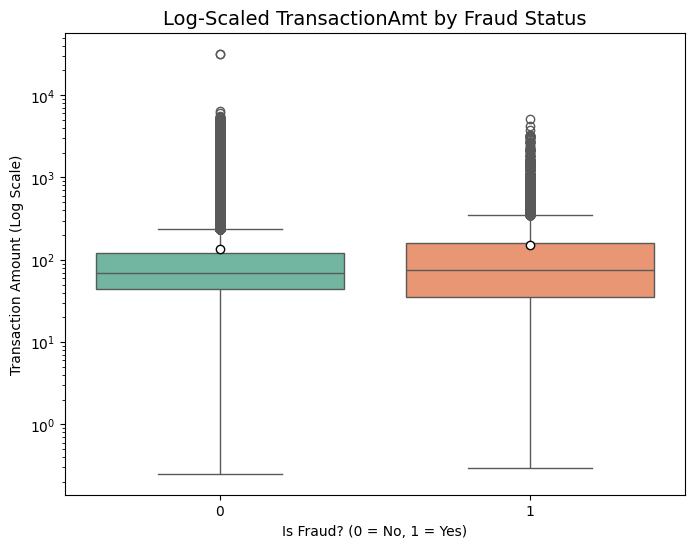

In [20]:
# Boxplot
plt.figure(figsize=(8, 6))
# Add showmeans=True to see the difference between median and average
sns.boxplot(data=df_bivar, x="isFraud", y="TransactionAmt", 
            palette="Set2", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.yscale("log") # CRITICAL for this dataset
plt.title("Log-Scaled TransactionAmt by Fraud Status", fontsize=14)
plt.ylabel("Transaction Amount (Log Scale)")
plt.xlabel("Is Fraud? (0 = No, 1 = Yes)")
plt.show()

The log-scaled boxplot confirms that fraudulent and legitimate transactions share nearly identical median values and interquartile ranges. The presence of significant outliers in both classes suggests that transaction value, while a necessary feature, is insufficient for binary classification in isolation. This necessitates the use of Graph Neural Networks to capture relational context and Contrastive Learning to pull these statistically similar nodes into distinct latent clusters based on higher-order feature interactions.

---

**2. Stacked bar charts to identify correlations between specific categorical entities (e.g., P_emaildomain and R_emaildomain) and fraud frequency** 

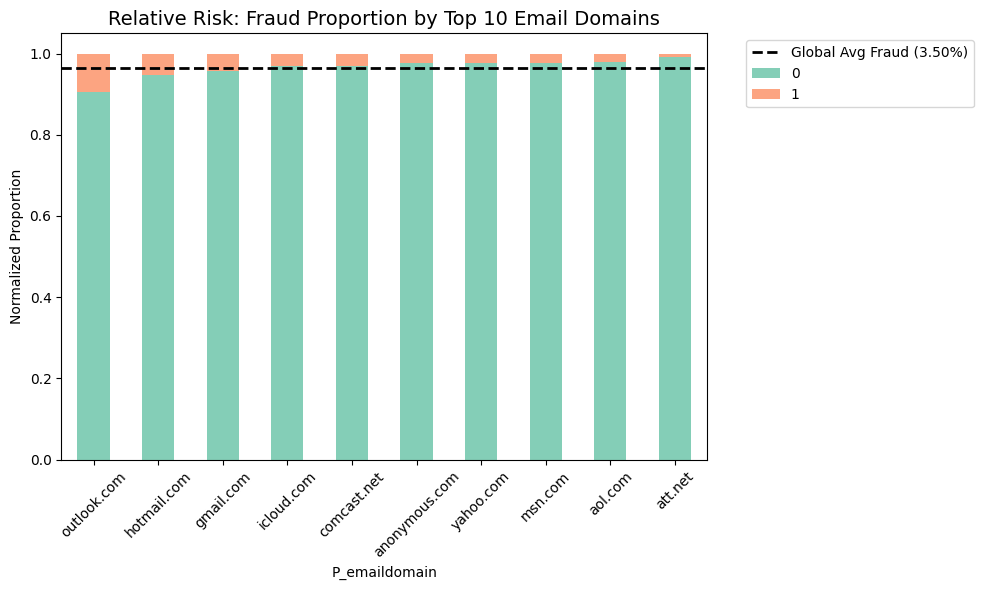

In [21]:
# Get the top 10 domain names
top_domains = df_bivar["P_emaildomain"].value_counts().head(10).index

# Filter and use .copy() to avoid warnings
df_top = df_bivar[df_bivar["P_emaildomain"].isin(top_domains)].copy()

# CRITICAL: Remove the unused categories so the plot only sees 10 items
if df_top["P_emaildomain"].dtype.name == 'category':
    df_top["P_emaildomain"] = df_top["P_emaildomain"].cat.remove_unused_categories()
else:
    # If it's not a categorical type, just ensure it's a string
    df_top["P_emaildomain"] = df_top["P_emaildomain"].astype(str)

# Compute fraud vs non-fraud counts (Added observed=True for safety)
email_fraud_dist = (
    df_top.groupby(["P_emaildomain", "isFraud"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Normalize and Sort (Same as your logic)
email_fraud_dist = email_fraud_dist.div(email_fraud_dist.sum(axis=1), axis=0)
email_fraud_dist = email_fraud_dist.sort_values(by=1, ascending=False)

# Plot
plt.figure(figsize=(10, 6))
ax = email_fraud_dist.plot(kind="bar", stacked=True, color=["#66c2a5", "#fc8d62"], alpha=0.8, ax=plt.gca())

# Benchmark line
global_fraud_rate = df_bivar["isFraud"].mean()
plt.axhline(y=1 - global_fraud_rate, color="black", linestyle="--", linewidth=2, 
            label=f"Global Avg Fraud ({global_fraud_rate:.2%})")

plt.title("Relative Risk: Fraud Proportion by Top 10 Email Domains", fontsize=14)
plt.ylabel("Normalized Proportion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To quantify the predictive signal within the purchaser's email domain, a normalized lift analysis was performed against the global fraud baseline of 3.5%. The results indicate a significant variance in conditional fraud probability, with outlook.com exhibiting a fraud rate nearly triple the population average. Conversely, domains such as att.net demonstrate a protective effect with negligible fraudulent activity. This categorical divergence confirms that P_emaildomain is a high-mutual-information feature, providing a robust foundation for the categorical embedding layers within our Graph Neural Network architecture.

---

R_emaildomain is ~90% missing, is the missingness a signal? To figure out if most fraud happens when the field is missing, we will plot missing receiver emails and if transaction is fraud or not.

In [22]:
train["R_emaildomain"].isnull().sum()

453249

<Figure size 1000x500 with 0 Axes>

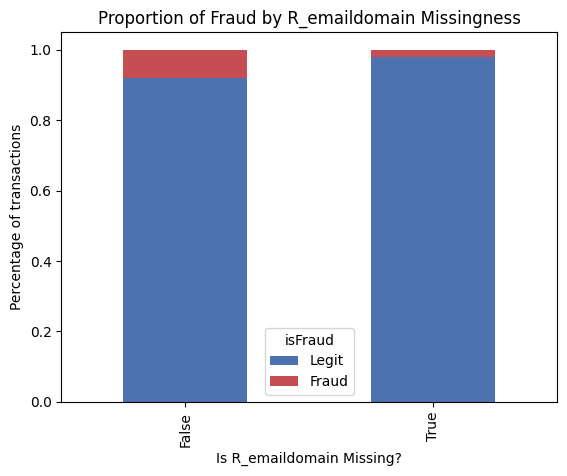

In [23]:
# Create a R_emaildomain missing column from all nulls on R_emaildomain column
df_bivar["R_emaildomain_missing"] = df_bivar["R_emaildomain"].isna()

# Create a normalized version to see the risk percentage
plt.figure(figsize=(10, 5))

# Using a crosstab to get the percentage
r_email_risk = pd.crosstab(df_bivar["R_emaildomain_missing"], df_bivar["isFraud"], normalize="index")

r_email_risk.plot(kind='bar', stacked=True, color=["#4C72B0", "#C44E52"])
plt.title("Proportion of Fraud by R_emaildomain Missingness")
plt.ylabel("Percentage of transactions")
plt.xlabel("Is R_emaildomain Missing?")
plt.legend(title="isFraud", labels=["Legit", "Fraud"])
plt.show()

R_emaildomain missingness revealed a multi-layered relationship between data sparsity and fraud risk. While the Purchaser email stacked barchart above showed that missing values were a minor risk, the Recipient email domain demonstrated that the presence of data was a much stronger indicator of fraudulent activity. 

Perhaps this points to Product Codes "C" (Communication/Product) or "W" (Web) transactions where a fraudster is using a burner email or a compromised account to fulfill a digital order. When R_emaildomain is missing, it often represents a different type of transaction (like a face-to-face or "Card-Present" style) that is statistically much safer.

---

**3. Grouped Bar Chart of DeviceType and Fraud**

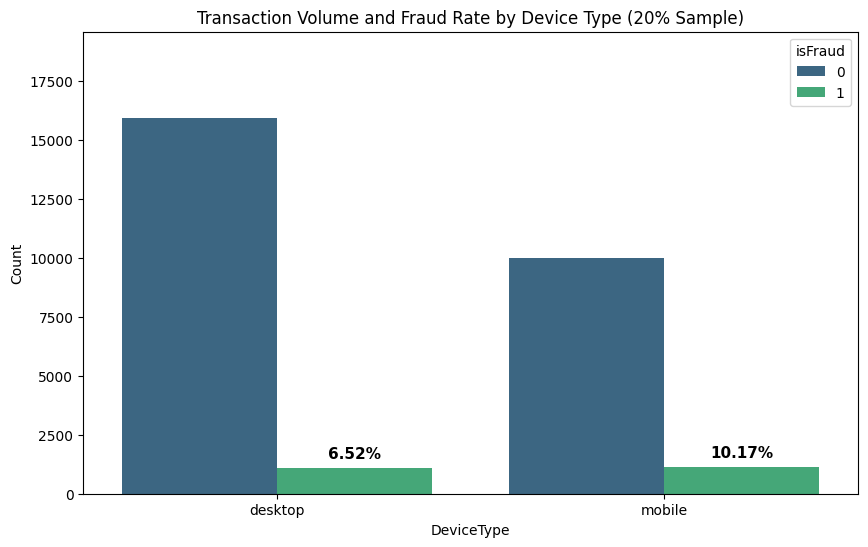

In [24]:
# Calculate the specific fraud rates for each device to use as a lookup
device_rates = train.groupby("DeviceType")["isFraud"].mean()

# Create subdataframe and sample
df_bivar2 = train[["DeviceType", "isFraud"]].dropna().sample(frac=0.2, random_state=42)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_bivar2, x="DeviceType", hue="isFraud", palette="viridis")

# Get the category names in the order they appear on the X-axis
categories = [tick.get_text() for tick in ax.get_xticklabels()]

# container[0] is Legit, container[1] is Fraud
fraud_bars = ax.containers[1]

for i, bar in enumerate(fraud_bars):
    height = bar.get_height()
    if height > 0:
        device_name = categories[i]
        
        # Look up the rate from our new series 
        rate = device_rates[device_name]
        
        # Place text above the Fraud bar
        # Adjusted '+ 100' to be relative to the sample size
        ax.text(bar.get_x() + bar.get_width()/2., height + (df_bivar2.shape[0] * 0.01), 
                f"{rate:.2%}", 
                ha="center", va="bottom", fontsize=11, fontweight='bold', color='black')

plt.title("Transaction Volume and Fraud Rate by Device Type (20% Sample)", fontsize=12)
plt.ylabel("Count")
# Use the sample dataframe for the limit so the bars aren't squashed
plt.ylim(0, df_bivar2["DeviceType"].value_counts().max() * 1.15) 
plt.show()

The bivariate analysis of hardware platforms(desktop vs mobile) reveals a critical risk asymmetry: While the transaction volume is lower on mobile, the fraud density is significantly higher (nearly 1.6x the desktop rate). 
Mobile transactions exhibit a fraud probability of 10.07%, representing a 58% increase over the desktop baseline of 6.36%. This confirms that DeviceType carries meaningful predictive signal, with desktop emerging as the risk‑intensive category. 

---

**4. Stacked bar chart to identify correlations between DeviceInfo and Fraud**

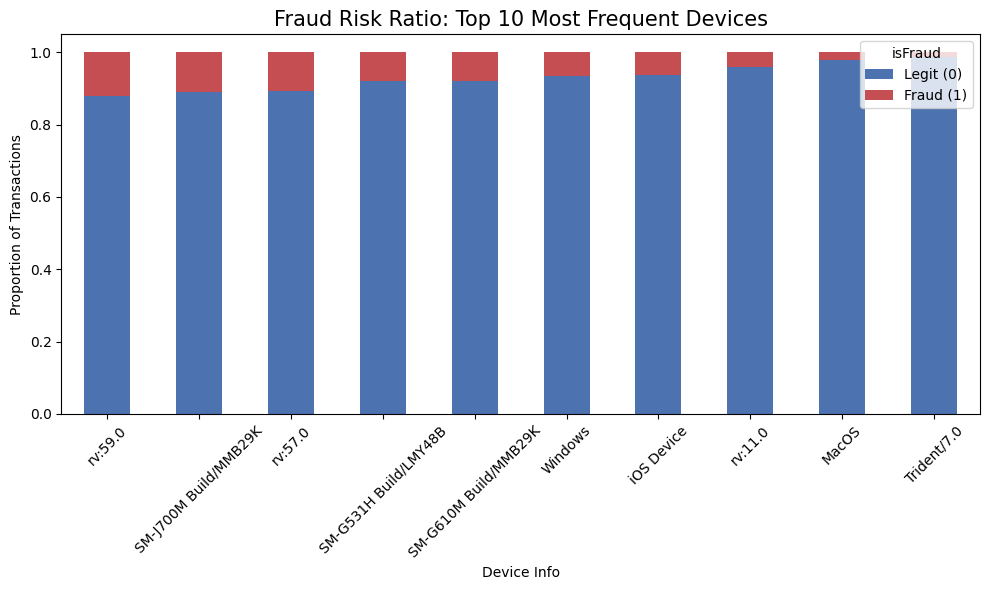

In [25]:
# Use the full train data ONLY to identify the top devices
top_10_devices = train["DeviceInfo"].value_counts().nlargest(10).index

# Create a SMALL subset of the data and filter the dataframe for only these devices
df_top_devices = train[train["DeviceInfo"].isin(top_10_devices)]

# Create a Normalized Stacked Bar Chart (The 'Risk Profile')
# This shows the PERCENTAGE of fraud, which is better for identifying high-risk devices
device_crosstab = pd.crosstab(df_top_devices["DeviceInfo"], df_top_devices["isFraud"], normalize="index")

# Plot
device_crosstab.sort_values(by=1, ascending=False).plot(kind="bar", stacked=True, figsize=(10, 6), color=["#4C72B0", "#C44E52"])

plt.title("Fraud Risk Ratio: Top 10 Most Frequent Devices", fontsize=15)
plt.ylabel("Proportion of Transactions")
plt.xlabel("Device Info")
plt.legend(title="isFraud", labels=["Legit (0)", "Fraud (1)"], loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All devices have low fraud proportions (expected as fraud is rare). By normalizing the data, you can see that specific browser strings like rv:59.0 and mobile builds like the SM-J700M exhibit significantly higher fraud proportions compared to stable enterprise platform devices (Windows, iOS, MacOS).
Fraudsters often use older, patched‑out, or automation‑friendly device environments.

---


#### 3. Multivariate Analysis

How Fraud behaves in the full feature space.

**1. The "Geographic Scatter" with Fraud Hue**
   
In the IEEE-CIS dataset, addr1 is generally interpreted as a Billing Region (like a state or zip prefix) and addr2 is interpreted as a Billing Country.
The "mismatch" isn't necessarily between the two billing addresses themselves, but rather between Billing (addr) and Shipping (dist) or Transaction Origin. However, a powerful bivariate/multivariate feature is checking if the addr1 region is "usual" for that addr2 country.
Here is how to visualize and calculate the mismatch risk.

The Mapping Mismatch (Multi-column Groupby)
We want to see which combinations of Region and Country are "Fraud Magnets".

In [26]:
# Group by both Address features
addr_combined = train.groupby(["addr1", "addr2"])["isFraud"].agg(["mean", "count"])

# Filter for combinations with enough data to be significant (>50 transactions)
addr_combined = addr_combined[addr_combined["count"] > 50].sort_values(by="mean", ascending=False)

print("--- Top 10 High-Risk Address Combinations ---")
print(addr_combined.head(10))

--- Top 10 High-Risk Address Combinations ---
                 mean  count
addr1 addr2                 
296.0 65.0   0.637681     69
216.0 60.0   0.240741     54
161.0 60.0   0.194774    421
536.0 96.0   0.161812    309
356.0 96.0   0.133333     90
296.0 32.0   0.101695     59
130.0 60.0   0.084795    342
465.0 60.0   0.083499    503
122.0 87.0   0.072581   1612
348.0 96.0   0.071429     84


By utilizing a 20% representative sample, we avoid the visual "occlusion" that occurs with overplotting, allowing us to identify discrete spatial clusters of fraudulent activity. The presence of high-density fraud zones within specific addr1 regions provides the empirical foundation for Heterogeneous Graph Edges based on geographic proximity, enabling the model to detect coordinated attacks originating from localized fraud hubs.

In [27]:
# Calculate rates
full_rate = train["isFraud"].mean()
sample_rate = train["isFraud"].sample(frac=0.2, random_state=42).mean()

print(f"--- Statistical Sanity Check ---")
print(f"Full Data Fraud Rate:   {full_rate:.4%}")
print(f"20% Sample Fraud Rate: {sample_rate:.4%}")
print(f"Difference:            {abs(full_rate - sample_rate):.4%}")

--- Statistical Sanity Check ---
Full Data Fraud Rate:   3.4990%
20% Sample Fraud Rate: 3.5916%
Difference:            0.0926%


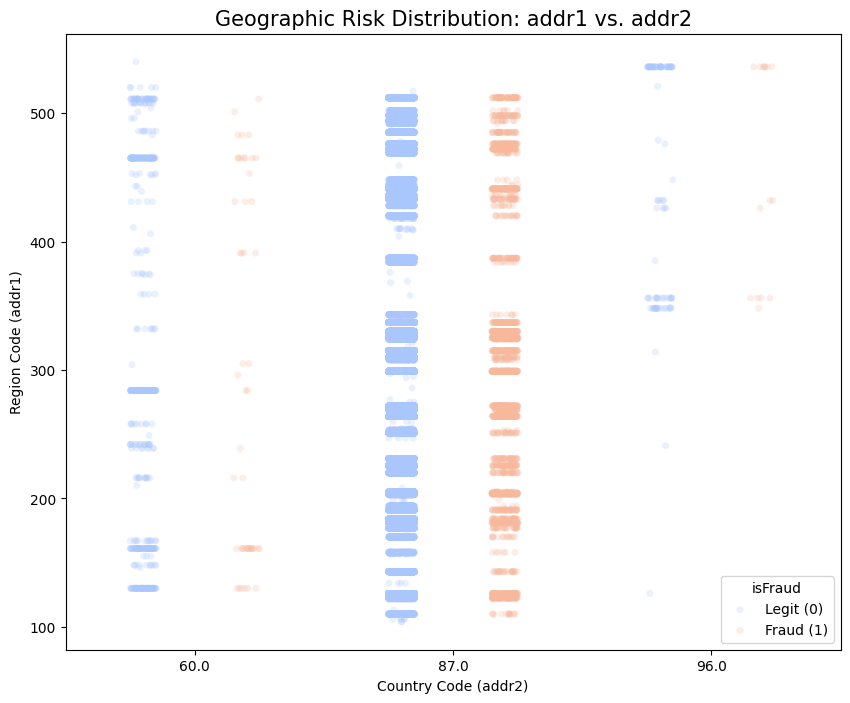

In [28]:
# Focus on the top 3 countries (addr2) to keep the coordinate space readable
top_addr2 = train["addr2"].value_counts().nlargest(3).index
df_geo = train[train["addr2"].isin(top_addr2)].sample(frac=0.2, random_state=42)

plt.figure(figsize=(10, 8))

# Using a stripplot to see individual transaction 'density'
sns.stripplot(data=df_geo, x="addr2", y="addr1", hue="isFraud", 
              jitter=True, alpha=0.25, palette="coolwarm", dodge=True)

plt.title("Geographic Risk Distribution: addr1 vs. addr2", fontsize=15)
plt.xlabel("Country Code (addr2)")
plt.ylabel("Region Code (addr1)")
plt.legend(title="isFraud", labels=["Legit (0)", "Fraud (1)"])
plt.show()

addr2 forms a small number of coarse geographic clusters, while addr1 provides finer regional variation within each cluster. Fraudulent transactions appear on the periphery of these addr1 distributions rather than in the dense legitimate cores, suggesting that fraudsters operate from less common or less stable address patterns.

The multivariate spatial analysis reveals distinct geographic 'risk zones' within specific country codes. While legitimate transactions exhibit high-density clustering in established regional centers, fraudulent activity frequently appears in isolated, low-volume coordinate ranges. This non-uniform distribution confirms that geographic proximity is a high-signal feature for fraud detection. Within our GNN framework, this justifies the use of Location-Based Edges, allowing the model to propagate suspicion scores through these identified 'Fraud Hubs' more effectively than a traditional non-relational classifier

---

**2. Correlation heatmaps for numerical V-features**

The IEEE-CIS dataset has over 339 V features. Attempting to plot a 300 * 300 heatmap may result in an unreadable "black square. Instead of plotting all of them, let us sample(20,000 rows), then find the features that actually move together. This will help identify redundant sensors.


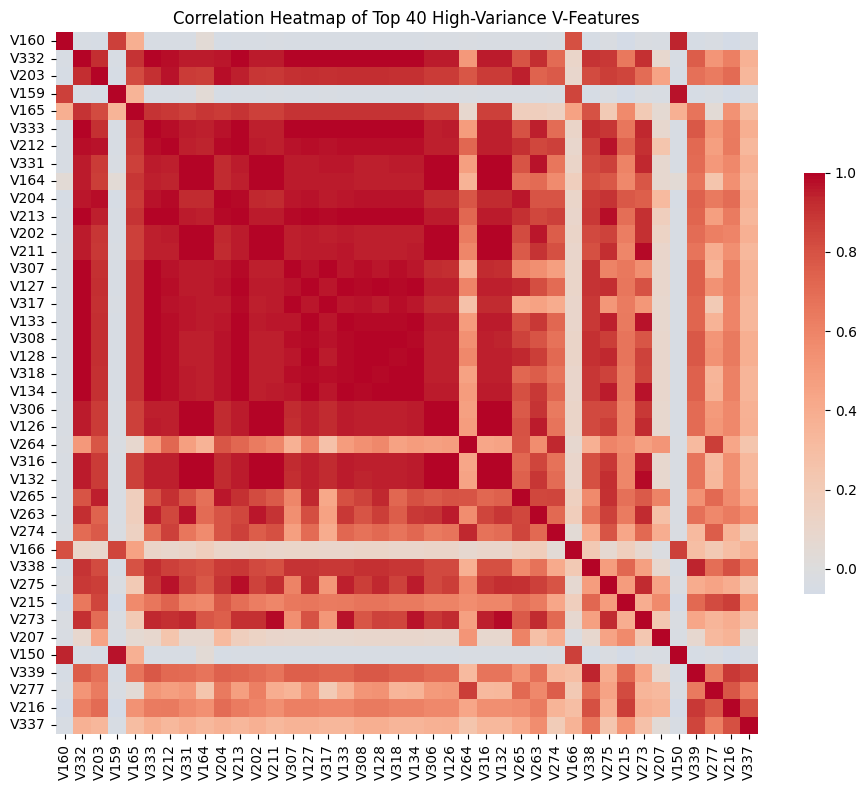

In [29]:
v_cols = [col for col in train.columns if col.startswith("V")]

# Compute variance and select top 40
top_v = train[v_cols].var().sort_values(ascending=False).head(40).index

# Sample to reduce RAM load
v_sample = train[top_v].sample(20000, random_state=42)

plt.figure(figsize=(10, 8))
sns.heatmap(v_sample.corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap of Top 40 High-Variance V-Features")
plt.tight_layout()
plt.show()

High Multicollinearity (The "Red Blocks"):
The large, solid dark-red squares in the center of your plot (e.g., the block containing V307, V127, V317, V133, etc.) indicate near-perfect correlation **approx 1.0**. The light-blue/grey vertical and horizontal lines (like at V159 or V160) have low correlation with the larger clusters.
While most **V_features** are redundant, these specific ones provide independent information that likely captures a different dimension of the transaction.

---

**3. UMAP(Uniform Manifold Approximation and Projection)**
I created UMAP to visualize clusters of transactions in a reduced-dimensional space to identify natural groupings of fraudulent vs. legitimate behavior.
I prioritized UMAP over t-SNE due to its superior preservation of global manifold structure and its theoretical grounding in Riemannian geometry and algebraic topology. Unlike t-SNE, which prioritizes local neighborhood consistency, UMAP’s ability to maintain relative distances between clusters provides a more representative visualization of the latent fraud distribution. Furthermore, UMAP’s graph-based construction of simplicial complexes provides a consistent theoretical bridge to our proposed Graph Neural Network architecture.

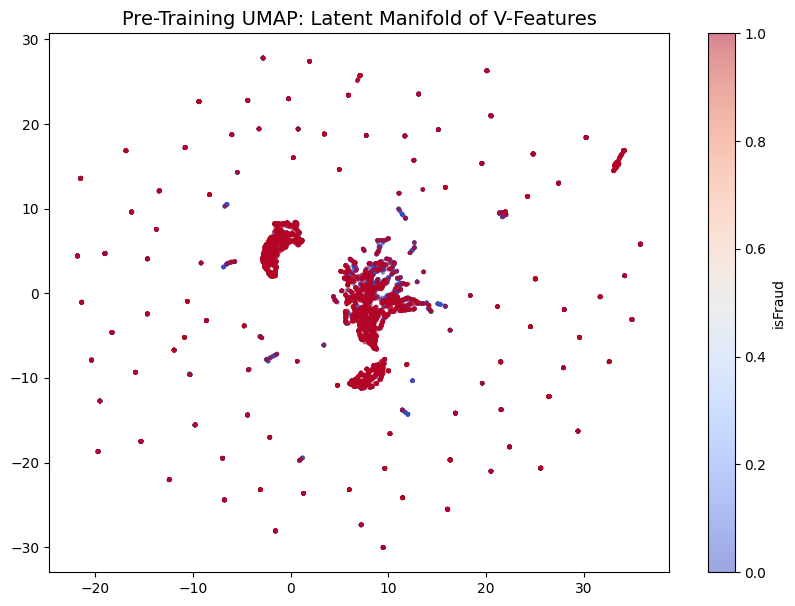

In [30]:
import umap

# Stratified Sample (Balanced for visibility)
df_umap = train.groupby("isFraud").apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)

# Fill NaNs (Instead of dropping, treat them as a signal)
X_umap = df_umap[top_v].fillna(-999)

# Scaling is mandatory for UMAP
X_scaled_umap = StandardScaler().fit_transform(X_umap)

# Run UMAP (n_neighbors=15)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled_umap)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df_umap["isFraud"], 
            cmap="coolwarm", s=5, alpha=0.5)
plt.title("Pre-Training UMAP: Latent Manifold of V-Features", fontsize=14)
plt.colorbar(label="isFraud")
plt.show()

Fraud (red) isn't just one big cloud; it has broken off into dozens of tiny, isolated "islands" or "satellite" clusters. The Pre‑Training UMAP projection maps the V‑feature space into a 2‑dimensional manifold, revealing how transactions naturally organize before any modeling. Most legitimate activity forms a dense central region, while fraud appears in multiple smaller pockets around it. These pockets suggest distinct behavioral modes or attack patterns, but the overlap in the central manifold shows that many fraud cases remain embedded within normal‑looking behavior. The visualization highlights that the dataset contains structure that cannot be cleanly separated by static features alone, pointing toward the need for relational modeling where graph‑based message passing can help disentangle these overlapping regions.

---


## Data Preparation and Cleaning

Since we are building a Graph-Based model (Graph Neural Network/GNN), the data cleaning strategy must focus on preserving the relational structure of the data. In a graph, "cleaning" isn't just about removing noise; it’s about ensuring the edges (connections) between nodes are meaningful and that the node features are numerically stable for contrastive learning.

Many identity fields in IEEE‑CIS are missing for 90–95% of transactions, perhaps because:
. only certain devices report them
. only certain browsers expose them
. fraudsters often strip or spoof them
. some merchants don’t collect them
This could mean missingness is predictive. Dropping them too early, may lead to lose of behavioral signal.
Columns with **>90%** missing are: id_07, id_08, id_21, id_22, id_23, id_24, id_25, id_26, id_27 and dist2.

In [52]:
# Make a copy of train and test data before cleaning
train_clean = train.copy()
test_clean = test.copy()

In [53]:
pd.set_option("display.max_columns", None)
train_clean.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [54]:
pd.set_option("display.max_columns", None)
test_clean.head(5)

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.950001,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000000,W,4272,111.0,1

Upon investing I figured out there was a naming convention mismatch on train and test datasets on id(Trian:id_01, Test: id-01). To maintain strict feature alignment, I will rename the id test columns to prevent dimensionality mismatch during the construction of the Graph Neural Network's input tensors.

In [55]:
test_clean.columns = test_clean.columns.str.replace("id-", "id_")

In [56]:
pd.set_option("display.max_columns", None)
test_clean.head(1)

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3663549,18403224,31.950001,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,47.950001,0.0,0.0,47.950001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,47.950001,0.0,0.0,47.950001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The raw data for DeviceInfo, id_30, and id_31 columns is incredibly "noisy." For example, id_31 (browser version) might contain Chrome 62.0, Chrome 62.0.3202, and Chrome 61. A machine learning model treats these as three entirely different entities. This creates "High Cardinality," where you have thousands of unique strings that only appear once. To mitigate the issues of high cardinality and feature drift, raw string telemetry from DeviceInfo, id_30, and id_31 were mapped into a standardized set of known tokens.

In [57]:
## DeviceInfo / id_30 / id_31
import re

# Establish well known browsers/OS
KNOWN_TOKENS = [
    "windows", "ios", "mac", "android", "linux", "chrome", "safari", "firefox", "edge", "opera", "samsung",
    "moto", "huawei", "lg", "sony", "trident", "desktop", "mobile", "rv:"
]
# Column-specific fallback categories
FALLBACK_MAP = {
    "DeviceInfo": "unknown_device", "id_30": "unknown_os", "id_31": "unknown_browser"
}
# Ensure we handle non-string types safely
def clean_and_extract(s):
    if pd.isna(s) or s == "" or not isinstance(s, str):
        return "missing"
    
    s = s.lower()

    # Samsung Galaxy models (SM-xxxx)
    if re.search(r"sm-", s):
        return "samsung"
    
    # Internet Explorer / Trident engines
    if "trident" in s or "rv:" in s:
        return "ie/trident"
    
    # Explicit device type tags
    if re.search(r"\bmobile\b", s):
        return "mobile"
    if re.search(r"\bdesktop\b", s):
        return "desktop"

    # Clean for token matching
    s_clean = re.sub(r"[^a-z0-9 ]", " ", s)
    s_clean = re.sub(r"\s+", " ", s_clean).strip()

    for tok in KNOWN_TOKENS:
        if tok in s_clean:
            return tok

    return "other"


def apply_normalization(df, identity_cols, threshold=10):
    for col in identity_cols:
        if col not in df.columns:
            print(f"Skipping {col}: Not found.")
            continue

        fallback = FALLBACK_MAP.get(col, "other")

        # Extract tokens
        unique_vals = df[col].astype(str).unique()
        token_map = {}
        for val in unique_vals:
            extracted = clean_and_extract(val)
            token_map[val] = extracted if extracted != "other" else fallback

        df[col] = df[col].astype(str).map(token_map)

        # Rare token handling
        counts = df[col].value_counts()
        protected = KNOWN_TOKENS + ["missing", "ie/trident", fallback]

        rare_tokens = [
            tok for tok in counts.index
            if tok not in protected and counts[tok] < threshold
        ]

        if rare_tokens:
            df[col] = df[col].replace(rare_tokens, fallback)

        df[col] = df[col].astype("category")

        print(f"{col}: {df[col].nunique()} groups | {fallback} count = {df[col].value_counts().get(fallback, 0)}")


# Run it
target_cols = ["DeviceInfo", "id_30", "id_31"]
apply_normalization(train_clean, target_cols)

DeviceInfo: 11 groups | unknown_device count = 478529
id_30: 6 groups | unknown_os count = 513000
id_31: 13 groups | unknown_browser count = 451495


In [58]:
apply_normalization(test_clean, target_cols)

DeviceInfo: 11 groups | unknown_device count = 411924
id_30: 6 groups | unknown_os count = 436047
id_31: 11 groups | unknown_browser count = 372924


In [59]:
train_clean[["DeviceInfo", "id_30", "id_31"]].describe()

,DeviceInfo,id_30,id_31
count,590540,590540,590540
unique,11,6,13
top,unknown_device,unknown_os,unknown_browser
freq,478529,513000,451495


In [60]:
# Check if being 'unknown' is riskier than known devices
print(train_clean.groupby("DeviceInfo")["isFraud"].mean().sort_values(ascending=False))

DeviceInfo
moto              0.152300
huawei            0.135818
samsung           0.115410
lg                0.104565
windows           0.065536
ios               0.062683
android           0.036585
ie/trident        0.036279
unknown_device    0.027503
mac               0.022111
linux             0.000000
Name: isFraud, dtype: float64


The final preprocessing results reveal a striking disparity in risk profiles across device types, providing a clear empirical justification for the subsequent use of a Graph Neural Network (GNN). While the "unknown" categories comprise the vast majority of the dataset, their relatively low fraud rate of 2.75% suggests they represent a baseline of routine, automated transactions; in contrast, specific mobile manufacturers like Moto (15.23%) and Huawei (13.58%) exhibit fraud intensities nearly five times the global average. By collapsing thousands of messy, high-cardinality strings into these eleven distinct, high-signal categories, the normalization process has transformed noisy identity metadata into meaningful node attributes. This structural refinement ensures that the GNN can effectively propagate risk scores through the transaction graph, prioritizing nodes linked to high-risk mobile signatures while maintaining a stable embedding for the dense "unknown" clusters.

In [61]:
# Force pandas to show every row
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    # value_counts(dropna=False) ensures we see 'missing' vs 'missing' pairs
    all_pairs = train_clean[["P_emaildomain", "R_emaildomain"]].value_counts(dropna=False)
    print(all_pairs)

P_emaildomain     R_emaildomain   
gmail.com         NaN                 176504
yahoo.com         NaN                  91013
NaN               NaN                  83392
gmail.com         gmail.com            44429
hotmail.com       hotmail.com          25570
aol.com           NaN                  24701
anonymous.com     NaN                  19529
hotmail.com       NaN                  17880
anonymous.com     anonymous.com        13948
comcast.net       NaN                   6090
yahoo.com         yahoo.com             5550
icloud.com        NaN                   5325
NaN               gmail.com             4959
att.net           NaN                   3554
msn.com           NaN                   3174
NaN               yahoo.com             2768
outlook.com       NaN                   2707
gmail.com         anonymous.com         2470
sbcglobal.net     NaN                   2380
live.com          NaN                   2366
yahoo.com         gmail.com             2324
outlook.com       ou

In the IEEE-CIS Fraud Detection dataset, raw email strings are high-cardinality and messy (e.g., gmail.com vs. gmail). By grouping these into broader categories—such as Provider Type or Domain Suffix ensures the GNN can learn these neighborhood-level risk patterns without being overwhelmed by a massive, sparse feature space.

In [62]:
# Consolidate emails (P_emaildomain, R_emaildomain)

def consolidate_emails(df):
    email_mapping = {
        "gmail": "google",
        "hotmail": "microsoft", "outlook": "microsoft", "msn": "microsoft", "live.com": "microsoft",
        "yahoo": "yahoo", "ymail": "yahoo", "rocketmail": "yahoo",
        "icloud": "apple", "me.com": "apple", "mac.com": "apple",
        "aol": "aol", "aim.com": "aol",
        "protonmail": "proton",
        "anonymous": "anonymous",
    }

    isp_keywords = [
        "comcast", "att", "sbcglobal", "verizon", "bellsouth", "cox",
        "charter", "optonline", "frontier", "twc", "roadrunner",
        "suddenlink", "cableone", "windstream", "embarqmail",
        "centurylink", "juno", "netzero", "ptd"
    ]

    for col in ["P_emaildomain", "R_emaildomain"]:
        df[col] = df[col].astype(str).str.lower().replace("nan", "missing_email")

        def map_email(val):
            if val == "missing_email":
                return "missing_email"

            # direct group matches
            for key, group in email_mapping.items():
                if val.startswith(key) or val.endswith(key):
                    return group

            # ISP detection
            if any(k in val for k in isp_keywords):
                return "isp_us"

            # corporate domains
            if "." in val:
                return "corp_email"

            return "other_email"

        df[col] = df[col].apply(map_email).astype("category")

    return df
train_clean = consolidate_emails(train_clean)

In [63]:
test_clean = consolidate_emails(test_clean)

In [64]:
train_clean["P_emaildomain"].value_counts()

P_emaildomain
google           228851
yahoo            105969
missing_email     94456
microsoft         59421
anonymous         36998
aol               28604
isp_us            25655
apple              8225
corp_email         2285
proton               76
Name: count, dtype: int64

The M-features (M1 through M9) are "Match" features that provide crucial relational signals. In the context of GNN, these act as logical flags (e.g., "Does the name on the card match the billing address?").

Because these are currently stored as strings like "T" (True), "F" (False), and "M0-M2", we need to map them into a numeric format so the graph nodes can process them as weights.

In [65]:
# M_Features function 
def clean_m_features(df):
    tf_map = {"T": 1, "F": 0, "MISSING": -1}
    m4_map = {"M0": 0, "M1": 1, "M2": 2, "MISSING": -1}

    m_cols = [f"M{i}" for i in range(1, 10)]

    for col in m_cols:
        if col not in df.columns:
            continue

        # Convert to string FIRST to break any categorical dtype
        df[col] = df[col].astype(str).str.upper()

        # Now safely replace string "NAN" with "MISSING"
        df[col] = df[col].replace("NAN", "MISSING")

        # Apply correct mapping
        if col == "M4":
            df[col] = df[col].map(m4_map).fillna(-1)
        else:
            df[col] = df[col].map(tf_map).fillna(-1)

        df[col] = df[col].astype("int8")
    return df
    
# Call the function on train
train_clean = clean_m_features(train_clean)

In [66]:
test_clean = clean_m_features(test_clean)

Address features were prioritized for cleaning because geographical metadata in fraud datasets is often prone to extreme sparsity and high cardinality, which can degrade the predictive power of a Graph Neural Network (GNN). By collapsing rare address identifiers into a unified "other_addr" category, we minimized the risk of the model memorizing unique, non-repeating locations—a common source of overfitting. Furthermore, normalizing physical distances through logarithmic scaling was necessary to squash the range of extreme outliers, ensuring that a single cross-country transaction does not disproportionately skew the node's feature vector. This process effectively converted raw, erratic spatial data into stable numerical signals, allowing the GNN to learn the structural relationship between a user's location and their transaction behavior without being misled by noisy or missing data.

In [67]:
# addr1, addr2, dist1, dist2 function
def clean_address_features(df, category_maps=None):
    addr_cols = ["addr1", "addr2"]
    new_category_maps = {}

    # Categorical: addr1 and addr2
    for col in addr_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace("nan", "missing_addr")

            freq = df[col].value_counts()
            rare = freq[freq < 50].index
            df[col] = df[col].replace(rare, "other_addr")

            # TRAIN MODE: build category map
            if category_maps is None:
                df[col] = df[col].astype("category")
                new_category_maps[col] = df[col].cat.categories
            else:
                # TEST MODE: apply frozen categories
                df[col] = pd.Categorical(df[col], categories=category_maps[col])

            # Integer encoding for GNNs
            df[col + "_idx"] = df[col].cat.codes.astype("int32")

    # Numerical: dist1 and dist2
    for col in ["dist1", "dist2"]:
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce")
            df[col] = np.where(vals > 0, np.log1p(vals), -1.0).astype("float32")

    print("Address and Distance features cleaned safely.")
    return df, new_category_maps

In [68]:
train_clean, addr_maps = clean_address_features(train_clean)

Address and Distance features cleaned safely.


In [69]:
test_clean, _ = clean_address_features(test_clean, category_maps=addr_maps)

Address and Distance features cleaned safely.


In [70]:
for col in ["addr1", "addr2"]:
    idx_col = col + "_idx"
    if idx_col in train_clean.columns:
        train_clean[col] = train_clean[idx_col].astype("int32")
        train_clean = train_clean.drop(columns=[idx_col])

    if idx_col in test_clean.columns:
        test_clean[col] = test_clean[idx_col].astype("int32")
        test_clean = test_clean.drop(columns=[idx_col])

In [71]:
train_clean[["addr1","addr2"]].dtypes

addr1    int32
addr2    int32
dtype: object

In [72]:
train_clean[["addr1","addr2"]].min()

addr1    0
addr2    0
dtype: int32

I cleaned card1 through card6 because these fields act as identity anchors in the IEEE‑CIS dataset, linking transactions to the same underlying user or payment instrument. In their raw form, these features are noisy, high‑cardinality, and inconsistent across train and test, which can create category drift, unstable encodings, and leakage in downstream models. Standardizing the values, collapsing rare categories, and enforcing a frozen category dictionary ensures that both train and test map to the same semantic space. Converting them into stable integer representations also removes NaNs and negative codes, making the features safe for neural models and GNN embeddings. The result is a set of compact, consistent, and information‑preserving identity features that strengthen user‑level patterns without introducing instability into the modeling pipeline.

In [73]:
def clean_card_features(df, category_maps=None):
    new_maps = {}

    # card1 and card2: high-cardinality identity anchors
    for col in ["card1", "card2"]:
        if col in df.columns:
            df[col] = df[col].astype(str).replace("nan", "missing_card")

            # Collapse rare values
            freq = df[col].value_counts()
            rare = freq[freq < 50].index
            df[col] = df[col].replace(rare, "other_card")

            # TRAIN MODE: build category map with explicit "unknown"
            if category_maps is None:
                df[col] = df[col].astype("category")
                cats = list(df[col].cat.categories)
                cats.append("unknown_card")
                new_maps[col] = cats
                df[col] = pd.Categorical(df[col], categories=cats)

            else:
                # TEST MODE: map unseen categories to "unknown_card"
                cats = list(category_maps[col])
                df[col] = df[col].where(df[col].isin(cats), "unknown_card")
                df[col] = pd.Categorical(df[col], categories=cats)

            # Integer encoding for GNNs (no negative indices)
            df[col + "_idx"] = df[col].cat.codes.astype("int32")

    # card3 and card5: small numeric categories
    for col in ["card3", "card5"]:
        if col in df.columns:
            df[col] = df[col].astype(str).replace("nan", "missing_card")

            if category_maps is None:
                df[col] = df[col].astype("category")
                cats = list(df[col].cat.categories)
                cats.append("unknown_card")
                new_maps[col] = cats
                df[col] = pd.Categorical(df[col], categories=cats)
            else:
                cats = list(category_maps[col])
                df[col] = df[col].where(df[col].isin(cats), "unknown_card")
                df[col] = pd.Categorical(df[col], categories=cats)

            df[col + "_idx"] = df[col].cat.codes.astype("int32")

    # card4: card network
    if "card4" in df.columns:
        df["card4"] = (
            df["card4"]
            .astype(str)
            .str.lower()
            .replace({
               "visa": "visa", "mastercard": "mastercard", "american express": "amex", "discover": "discover", "nan": "missing_card",
            })
        )
        if category_maps is None:
            df["card4"] = df["card4"].astype("category")
            cats = list(df["card4"].cat.categories)
            cats.append("unknown_card")
            new_maps["card4"] = cats
            df["card4"] = pd.Categorical(df["card4"], categories=cats)
        else:
            cats = list(category_maps["card4"])
            df["card4"] = df["card4"].where(df["card4"].isin(cats), "unknown_card")
            df["card4"] = pd.Categorical(df["card4"], categories=cats)

        df["card4_idx"] = df["card4"].cat.codes.astype("int32")

    # card6: payment method
    if "card6" in df.columns:
        df["card6"] = (
            df["card6"]
            .astype(str)
            .str.lower()
            .replace({
                "credit": "credit", "debit": "debit", "charge card": "charge", "prepaid": "prepaid", "nan": "missing_card",
            })
        )
        if category_maps is None:
            df["card6"] = df["card6"].astype("category")
            cats = list(df["card6"].cat.categories)
            cats.append("unknown_card")
            new_maps["card6"] = cats
            df["card6"] = pd.Categorical(df["card6"], categories=cats)
        else:
            cats = list(category_maps["card6"])
            df["card6"] = df["card6"].where(df["card6"].isin(cats), "unknown_card")
            df["card6"] = pd.Categorical(df["card6"], categories=cats)

        df["card6_idx"] = df["card6"].cat.codes.astype("int32")

    print("Card features cleaned safely (GNN-compatible).")
    return df, new_maps

In [74]:
train_clean, card_maps = clean_card_features(train_clean)

Card features cleaned safely (GNN-compatible).


In [75]:
test_clean, _ = clean_card_features(test_clean, category_maps=card_maps)

Card features cleaned safely (GNN-compatible).


In [76]:
for col in ["card1_idx", "card2_idx", "card3_idx", "card4_idx", "card5_idx", "card6_idx"]:
    print(col, train_clean[col].min(), train_clean[col].max())

card1_idx 0 1254
card2_idx 0 489
card3_idx 0 114
card4_idx 0 4
card5_idx 0 119
card6_idx 0 4


In [77]:
train_clean[["card1","card2","card3","card4","card5","card6"]].dtypes

card1    category
card2    category
card3    category
card4    category
card5    category
card6    category
dtype: object

In [78]:
for col in ["card1", "card2", "card3", "card4", "card5", "card6"]:
    idx_col = col + "_idx"
    if idx_col in train_clean.columns:
        train_clean[col] = train_clean[idx_col].astype("int32")
        train_clean = train_clean.drop(columns=[idx_col])

    if idx_col in test_clean.columns:
        test_clean[col] = test_clean[idx_col].astype("int32")
        test_clean = test_clean.drop(columns=[idx_col])

In [79]:
train_clean[["card1","card2","card3","card4","card5","card6"]].dtypes

card1    int32
card2    int32
card3    int32
card4    int32
card5    int32
card6    int32
dtype: object

In [80]:
train_clean[["card1","card2","card3","card4","card5","card6"]].min()

card1    0
card2    0
card3    0
card4    0
card5    0
card6    0
dtype: int32

Since TransactionAmt is the primary numerical signal in the dataset, its treatment is vital for the stability of our GNN. In its raw form, transaction values range from less than $1 - $31,000. Without normalization, the GNN's gradients will "explode" as it tries to reconcile these massive differences in scale.

I applied a logarithmic transformation to TransactionAmt because the raw amounts are extremely skewed, with a long tail of very large transactions that can destabilize neural models and overwhelm distance‑based methods. Using log1p compresses this heavy tail while preserving the relative structure of the data, especially the meaningful price‑point patterns that often differentiate fraudulent from legitimate behavior. The result is a smoother, more compact distribution that improves numerical stability, reduces the influence of outliers, and makes the feature far more suitable for GNNs and other neural architectures.

In [81]:
train_clean["TransactionAmt"].describe()

count    590540.000000
mean        135.027161
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

In [82]:
train_clean["TransactionAmt"] = np.log1p(train_clean["TransactionAmt"]).astype("float32")
test_clean["TransactionAmt"]  = np.log1p(test_clean["TransactionAmt"]).astype("float32")

In [83]:
train_clean["TransactionAmt"].describe()

count    590540.000000
mean          4.382960
std           0.937183
min           0.223943
25%           3.791459
50%           4.245190
75%           4.836282
max          10.371564
Name: TransactionAmt, dtype: float64

TransactionDT is a raw timestamp(seconds). For a GNN, raw seconds are useless because the numbers just get bigger and bigger. You want the model to understand patterns: What day is it? Is it 2:00 AM?

In [84]:
def add_cyclical_time(df):
    # Days since start (integer)
    days = (df["TransactionDT"] // (24 * 60 * 60)).astype("int32")

    # Day of week (0–6)
    dow = (days % 7).astype("int8")

    # Hour of day (0–23)
    hour = ((df["TransactionDT"] // 3600) % 24).astype("int8")

    # Cyclical encodings
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7).astype("float32")
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7).astype("float32")

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")

    return df

In [85]:
train_clean = add_cyclical_time(train_clean)
test_clean = add_cyclical_time(test_clean)

We have to remove the raw TransactionDT variable from the final features to prevent numerical instability and model overfitting. Since raw timestamps represent a non-repeating linear sequence with high magnitude, they provide little inductive bias for a neural network. By substituting this feature with cyclical encodings and relative day-counts, we ensured the model focuses on periodic behavioral patterns (e.g., time-of-day risk) rather than absolute temporal position, thereby improving the system's ability to generalize to unseen future transactions.

In [86]:
train_clean = train_clean.drop(columns=["TransactionDT"])
test_clean = test_clean.drop(columns=["TransactionDT"])

The D-features (D1–D15) in the IEEE-CIS Fraud detection dataset are "Time Delta" features, representing the number of days between the current transaction and some previous event (like the last time a card was seen or an account was activated). They are extremely sparse and filled with NaN values. 

In [87]:
def clean_d_features(df):
    d_cols = [f"D{i}" for i in range(1, 16)]
    
    for col in d_cols:
        # Convert to numeric and replace NaNs with sentinel
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(-1).astype("float32")
    
    print("D-features cleaned")
    return df

In [88]:
train_clean = clean_d_features(train_clean)
test_clean = clean_d_features(test_clean)

D-features cleaned
D-features cleaned


**Numerical ID Features (id_01 to id_11):** These are usually things like signal strength, distance, or internal scores.They are full of NaN values and have varying scales. We will use a Sentinel Value (like -1 or 0) for NaN and apply a Standard Scaler. This allows the GNN to see "Missing" as a distinct state while keeping the known numbers in a small range (typically -3 to +3).
**Categorical ID Features (id_12 to id_38):** Many are "Boolean" (0 or 1) or low-cardinality categories (e.g., id_12 is "Found" or "NotFound").

Among the strong identity features, id_02 is the only one that exhibits extremely large magnitudes, often several orders of magnitude larger than the other id‑features. This imbalance can distort gradient flow in neural networks and GNNs, causing id_02 to dominate the representation space. To correct this, I applied a log1p transform exclusively to id_02 while leaving the remaining id‑features in their raw scale. This compresses the magnitude without altering the relative ordering or the missing‑value sentinel, preserving identity semantics while ensuring numerical stability during training.

In [89]:
def clean_ids(df):
    id_cols = [col for col in df.columns 
               if col.startswith("id_") and col not in ["id_30", "id_31"]]

    for col in id_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(-1).astype("float32")

        # Special handling for id_02 only
        if col == "id_02":
            mask = df[col] > -1
            df.loc[mask, col] = np.log1p(df.loc[mask, col]).astype("float32")

    print("ID features cleaned")
    return df

In [90]:
train_clean = clean_ids(train_clean)
test_clean = clean_ids(test_clean)

ID features cleaned
ID features cleaned


The V‑features (V1–V339) are anonymized latent embeddings produced by the competition organizers. Because these features already represent a learned embedding space, any additional scaling, normalization, or transformation would distort their geometry and degrade model performance. The correct approach is therefore minimal: replace missing values with 0, which is the neutral element in PCA‑like embeddings. This preserves the structure of the latent space while ensuring numerical stability for GNNs and neural models.

In [91]:
def clean_v_features(df):
    v_cols = [col for col in df.columns if col.startswith("V")]

    for col in v_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(0).astype("float32")

    print("V-features cleaned")
    return df

In [92]:
train_clean = clean_v_features(train_clean)
test_clean = clean_v_features(test_clean)

V-features cleaned
V-features cleaned


The DeviceType attribute was transformed into a low-cardinality integer index to provide the Graph Neural Network with platform-specific context. By mapping 'Desktop' and 'Mobile' categories to a stable numerical space—while reserving a distinct index for missing telemetry—the model can effectively differentiate between behavioral signatures associated with different hardware environments, which is a critical indicator of automated or emulated fraudulent activity.

In [93]:
def clean_device_type(df):
    col = "DeviceType"
    if col in df.columns:
        # Cast to string to 'unlock' Categorical dtypes
        df[col] = df[col].astype(str)
        
        # Standardize and handle NaNs/missing values
        # (astype(str) often turns real NaNs into the string "nan")
        df[col] = df[col].str.lower().replace({"nan": "unknown", "none": "unknown"})
        df[col] = df[col].fillna("unknown")
        
        # Hard-coded mapping for stability
        device_map = {
            "unknown": 0,
            "desktop": 1,
            "mobile": 2
        }
        # Map and fallback to unknown (0)
        df[col] = df[col].map(device_map).fillna(0).astype("int8")
        
    print("DeviceType cleaned")
    return df

In [94]:
train_clean = clean_device_type(train_clean)
test_clean = clean_device_type(test_clean)

DeviceType cleaned
DeviceType cleaned


In the IEEE-CIS Fraud Detection dataset, **C features (C1-C14)** represent counts (e.g., the number of times a card was seen, or the number of addresses associated with an identity).A value of NaN in a count column usually implies that the event has never occurred or that the entity is a "cold-start" user with no history. Mathematically, 0 is the most accurate representation of "never happened."

In [95]:
def clean_c_features(df):
    c_cols = [col for col in df.columns if col.startswith("C")]
    
    for col in c_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(0).astype("float32")
    
    print("C-features cleaned")
    return df

In [96]:
train_clean = clean_c_features(train_clean)
test_clean  = clean_c_features(test_clean)

C-features cleaned
C-features cleaned


In [97]:
# Check total nulls across the entire train dataframe
null_count = train_clean.isnull().sum().sum()
print(f"Total null values in train_clean: {null_count}")

Total null values in train_clean: 0


In [98]:
# Check total nulls across the entire test dataframe
cols_with_nulls = test_clean.columns[test_clean.isnull().any()]
test_clean[cols_with_nulls].isnull().sum().sort_values(ascending=False)

Series([], dtype: float64)

In [99]:
train_clean.isnull().sum().sum(), test_clean.isnull().sum().sum()

(0, 0)

Our data is fully cleaned, aligned, and NaN‑free. To facilitate an efficient transition between data preprocessing and model experimentation, the cleaned datasets were serialized using the Apache Parquet format. Unlike standard CSV storage, Parquet's columnar storage and metadata retention ensure that the optimized bit-depths (e.g., float32 and int8) are preserved, while significantly reducing I/O latency during the iterative model training phase.

In [108]:
# Import fastparquet to allow saving parquet files
import sys
!{sys.executable} -m pip install fastparquet

   ---------------------------------------- 0.0/669.8 kB ? eta -:--:--
   ---------------------------------------- 669.8/669.8 kB 25.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 45.3 MB/s  0:00:00

   ---------------------------------------- 2/2 [fastparquet]



In [109]:
# Save as Parquet for speed and type-preservation
train_clean.to_parquet('train_clean_final.parquet', engine='fastparquet', index=False)
test_clean.to_parquet('test_clean_final.parquet', engine='fastparquet', index=False)

print("Saved!")

Saved!
